# Week 1 — Python for Finance Foundations
Setting up the environment and pulling real market data with yfinance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Setup complete!")

pandas: 3.0.2
numpy: 2.4.4
Setup complete!


In [2]:
spy = yf.download("SPY", period="1y")["Close"].squeeze()

print("Shape:", spy.shape)
print("Date range:", spy.index[0].date(), "to", spy.index[-1].date())
spy.tail()

[*********************100%***********************]  1 of 1 completed

Shape: (251,)
Date range: 2025-06-26 to 2026-06-25


Date
2026-06-18    746.739990
2026-06-22    744.390015
2026-06-23    733.580017
2026-06-24    733.239990
2026-06-25    734.299988
Name: SPY, dtype: float64

In [3]:
spy = yf.download("SPY", period="1y")["Close"].squeeze()

print("Shape:", spy.shape)
print("Date range:", spy.index[0].date(), "to", spy.index[-1].date())
spy.tail()

[*********************100%***********************]  1 of 1 completed

Shape: (251,)
Date range: 2025-06-26 to 2026-06-25


Date
2026-06-18    746.739990
2026-06-22    744.390015
2026-06-23    733.580017
2026-06-24    733.239990
2026-06-25    734.299988
Name: SPY, dtype: float64

In [4]:
close = spy.copy()

print(close.describe())

returns = close.pct_change().dropna()
print("\nAvg daily return:", round(returns.mean() * 100, 4), "%")
print("Daily volatility:", round(returns.std() * 100, 4), "%")

count    251.000000
mean     674.240336
std       36.437452
min      605.164612
25%      651.728882
50%      674.243958
75%      688.386688
max      757.618225
Name: SPY, dtype: float64

Avg daily return: 0.0805 %
Daily volatility: 0.785 %


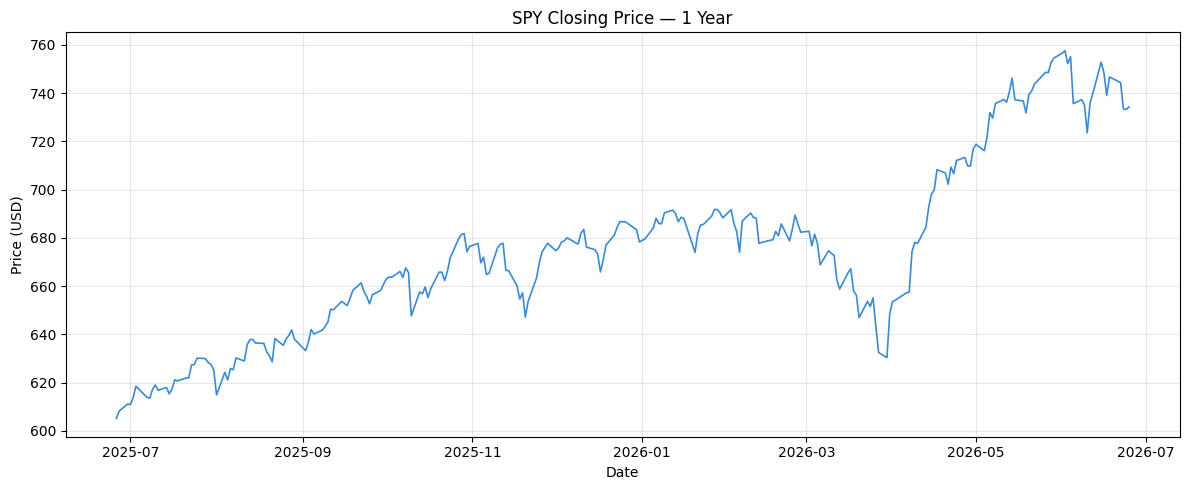

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(close.index, close.values, linewidth=1.2, color="#378ADD")
plt.title("SPY Closing Price — 1 Year")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
tickers = ["SPY", "QQQ", "GLD", "TLT"]
data = yf.download(tickers, period="1y")["Close"]
data.columns = data.columns.get_level_values(0)

print(data.shape)
data.tail()

[*********************100%***********************]  4 of 4 completed

(251, 4)


Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-06-18,387.119995,739.807007,746.739990,86.750000
2026-06-22,384.589996,737.950012,744.390015,86.089996
2026-06-23,377.320007,713.650024,733.580017,86.199997
2026-06-24,365.920013,710.619995,733.239990,87.379997
2026-06-25,369.459991,716.380005,734.299988,87.349998


In [7]:
print(data.isnull().sum())

data_clean = data.dropna()
print("Rows before:", len(data), "| After:", len(data_clean))

Ticker
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64
Rows before: 251 | After: 251


In [8]:
returns = data_clean.pct_change().dropna()

summary = pd.DataFrame({
    "Ann. Return (%)": (returns.mean() * 252 * 100).round(2),
    "Ann. Volatility (%)": (returns.std() * (252**0.5) * 100).round(2),
    "Sharpe (approx)": (
        (returns.mean() * 252) / (returns.std() * (252**0.5))
    ).round(2)
})

print(summary)

        Ann. Return (%)  Ann. Volatility (%)  Sharpe (approx)
Ticker                                                       
GLD               22.65                27.82             0.81
QQQ               29.45                17.96             1.64
SPY               20.28                12.46             1.63
TLT                4.26                 9.57             0.45


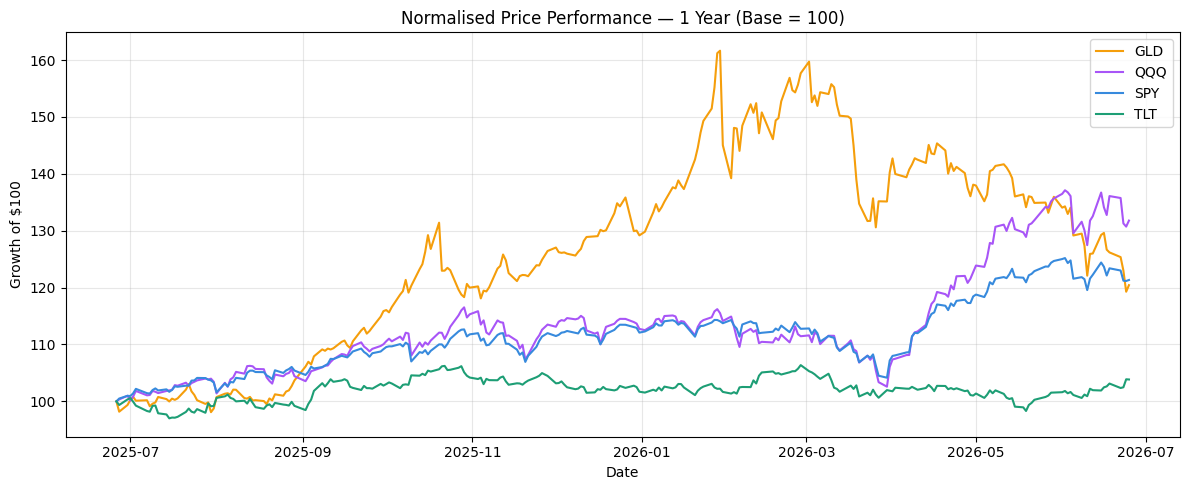

In [9]:
normalised = (data_clean / data_clean.iloc[0]) * 100

plt.figure(figsize=(12, 5))
colors = {"SPY": "#378ADD", "QQQ": "#A855F7", "GLD": "#F59E0B", "TLT": "#1D9E75"}

for ticker in normalised.columns:
    plt.plot(normalised.index, normalised[ticker],
             label=ticker, linewidth=1.5,
             color=colors.get(ticker, "#888"))

plt.title("Normalised Price Performance — 1 Year (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Growth of $100")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What this notebook covers
- Downloaded 1 year of daily OHLCV data for SPY, QQQ, GLD, TLT using yfinance
- Cleaned missing values with dropna()
- Computed annualised return, volatility and Sharpe ratio for each asset
- Plotted normalised price performance to compare growth across asset classes

## Key observations
- QQQ outperformed SPY but with higher volatility
- GLD showed low correlation with equities (useful for diversification)
- TLT underperformed in a high interest rate environment